In [1]:
import torch
import pandas as pd
from transformers import BertTokenizer, BertForSequenceClassification, Trainer, TrainingArguments
from sklearn.model_selection import train_test_split

In [3]:
# 1. TAHAP PRE-PROCESSING [cite: 53, 54]
def clean_comment(text):
    import re
    # Mengubah ke huruf kecil (Case Folding)
    text = text.lower()
    # Menghapus URL dan Username (@user)
    text = re.sub(r'http\S+|@\S+', '', text)
    # Menghapus karakter non-alfanumerik (Emoji/Simbol) [cite: 54]
    text = re.sub(r'[^a-z\s]', '', text)
    return text

In [4]:
# 2. MEMUAT DATASET [cite: 55, 57]
# Diasumsikan Anda memiliki file 'comments_gaming.csv' dengan kolom: 'comment', 'aspect_class', 'sentiment_class'
def load_data(file_path):
    df = pd.read_csv(file_path)
    df['comment'] = df['comment'].apply(clean_comment)
    return df

In [3]:
import pandas as pd
import torch
import torch.nn as nn
from transformers import AutoTokenizer, BertModel
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split

# ==========================================
# STEP 1: LOAD & SPLIT DATASET (70/15/15)
# ==========================================
# Membaca berkas berlabel menggunakan separator titik koma (;)
df = pd.read_csv('comments_labeled.csv', sep=';')

# Membuat kolom kombinasi aspek + sentimen untuk stratifikasi [cite: 105, 130]
df['stratify_col'] = df['aspect_class'].astype(str) + "_" + df['sentiment_class'].astype(str)

# Filter kombinasi kelas ekstrem yang hanya memiliki 1 member agar tidak merusak stratified split
class_counts = df['stratify_col'].value_counts()
rare_classes = class_counts[class_counts < 2].index.tolist()

if len(rare_classes) > 0:
    print(f"[Info] Menghapus {len(rare_classes)} kombinasi kelas yang terlalu langka: {rare_classes}")
    df = df[~df['stratify_col'].isin(rare_classes)]

# Pembagian data tahap 1 (70% Train, 30% Gabungan Val & Test) [cite: 123, 130, 165]
train_df, val_test_df = train_test_split(
    df, 
    test_size=0.30, 
    random_state=41, # Fixed random seed untuk reproducibility 
    stratify=df['stratify_col'] # [cite: 130, 165]
)

# Pembagian data tahap 2 (15% Validation, 15% Testing dari total dataset) [cite: 123, 130, 165]
val_test_counts = val_test_df['stratify_col'].value_counts()
rare_val_test = val_test_counts[val_test_counts < 2].index.tolist()

if len(rare_val_test) > 0:
    val_df, test_df = train_test_split(val_test_df, test_size=0.50, random_state=41)
else:
    val_df, test_df = train_test_split(val_test_df, test_size=0.50, random_state=41, stratify=val_test_df['stratify_col'])

# Hapus kolom pembantu stratifikasi
train_df = train_df.drop(columns=['stratify_col'])
val_df = val_df.drop(columns=['stratify_col'])
test_df = test_df.drop(columns=['stratify_col'])

print(f"[Sukses] Data Terbagi -> Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}\n")

[Info] Menghapus 2 kombinasi kelas yang terlalu langka: ['gameplay_negative', 'graphics_negative']
[Sukses] Data Terbagi -> Train: 719 | Val: 154 | Test: 155



In [9]:
# ==========================================
# STEP 2: PREPARE DATASET & TOKENIZER
# ==========================================
MAX_LEN = 128 # [cite: 131]
BATCH_SIZE = 16 # [cite: 131]
LR = 2e-5 # [cite: 131]
EPOCHS = 4 # [cite: 131]

# Silakan pilih model yang ingin diuji coba [cite: 86]
MODEL_NAME = "indobenchmark/indobert-base-p1"       # Cabang A: IndoBERT [cite: 86]
# MODEL_NAME = "indobenchmark/indobert-base-p2"

print(f"Memuat tokenizer untuk {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class YouTubeDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_len):
        self.data = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len
        
        # PERBAIKAN: Mengubah semua key menjadi huruf kecil sesuai isi berkas CSV Anda
        self.aspect_map = {
            'game_general': 0,
            'gameplay': 1, 
            'graphics': 2, 
            'story': 3, 
            'streamer': 4, 
            'other': 5,
            'off_topic': 5 
        }
        
        # PERBAIKAN: Mengubah menjadi huruf kecil (positive, negative, neutral)
        self.sentiment_map = {
            'positive': 0, 
            'negative': 1, 
            'neutral': 2
        }
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, index):
        row = self.data.iloc[index]
        comment = str(row['comment_text'])
        
        inputs = self.tokenizer(
            comment,
            padding='max_length',
            truncation=True,
            max_length=self.max_len,
            return_token_type_ids=True,
            return_tensors='pt'
        )
        
        return {
            'input_ids': inputs['input_ids'].flatten(),
            'attention_mask': inputs['attention_mask'].flatten(),
            'token_type_ids': inputs['token_type_ids'].flatten(),
            'aspect_label': torch.tensor(self.aspect_map[row['aspect_class']], dtype=torch.long),
            'sentiment_label': torch.tensor(self.sentiment_map[row['sentiment_class']], dtype=torch.long)
        }

train_dataset = YouTubeDataset(train_df, tokenizer, MAX_LEN)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

Memuat tokenizer untuk indobenchmark/indobert-base-p1...


In [10]:
# ==========================================
# STEP 3: ARCHITECTURE & FINE-TUNING LOOP
# ==========================================
class ABSAMultiTaskModel(nn.Module):
    def __init__(self, model_name, num_aspects=6, num_sentiments=3):
        super(ABSAMultiTaskModel, self).__init__()
        # TAMBAHKAN: ignore_mismatched_sizes=True agar bobot layer klasifikasi bawaan diabaikan dan di-reset otomatis
        self.bert = BertModel.from_pretrained(model_name, ignore_mismatched_sizes=True)
        hidden_size = self.bert.config.hidden_size
        
        self.aspect_classifier = nn.Linear(hidden_size, num_aspects)
        self.sentiment_classifier = nn.Linear(hidden_size, num_sentiments)
        
    def forward(self, input_ids, attention_mask=None, token_type_ids=None):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids)
        pooled_output = outputs[1]
        
        aspect_logits = self.aspect_classifier(pooled_output)
        sentiment_logits = self.sentiment_classifier(pooled_output)
        
        return aspect_logits, sentiment_logits

# Setup Environment Pytorch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ABSAMultiTaskModel(MODEL_NAME).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR) # Menggunakan Adam Optimizer [cite: 131]
criterion = nn.CrossEntropyLoss()

print(f"\n[Mulai] Membuka Pelatihan ({MODEL_NAME}) di perangkat: {device}")
model.train()

for epoch in range(EPOCHS):
    total_loss = 0
    for step, batch in enumerate(train_loader):
        optimizer.zero_grad()
        
        input_ids = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        token_type = batch['token_type_ids'].to(device)
        
        aspect_labels = batch['aspect_label'].to(device)
        sentiment_labels = batch['sentiment_label'].to(device)
        
        aspect_logits, sentiment_logits = model(input_ids, mask, token_type)
        
        # Menghitung loss multi-task
        loss_aspect = criterion(aspect_logits, aspect_labels)
        loss_sentiment = criterion(sentiment_logits, sentiment_labels)
        loss = loss_aspect + loss_sentiment
        
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        
        if step % 20 == 0:
            print(f"Epoch {epoch+1}/{EPOCHS} | Step {step}/{len(train_loader)} | Loss Kontemporer: {loss.item():.4f}")
            
    print(f"=== Selesai Epoch {epoch+1} -> Rata-Rata Loss Tahap Ini: {total_loss/len(train_loader):.4f} ===\n")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


[Mulai] Membuka Pelatihan (indobenchmark/indobert-base-p1) di perangkat: cpu
Epoch 1/4 | Step 0/45 | Loss Kontemporer: 3.7954
Epoch 1/4 | Step 20/45 | Loss Kontemporer: 0.9659
Epoch 1/4 | Step 40/45 | Loss Kontemporer: 1.6554
=== Selesai Epoch 1 -> Rata-Rata Loss Tahap Ini: 1.5719 ===

Epoch 2/4 | Step 0/45 | Loss Kontemporer: 0.8671
Epoch 2/4 | Step 20/45 | Loss Kontemporer: 0.9114
Epoch 2/4 | Step 40/45 | Loss Kontemporer: 0.5983
=== Selesai Epoch 2 -> Rata-Rata Loss Tahap Ini: 0.8925 ===

Epoch 3/4 | Step 0/45 | Loss Kontemporer: 0.4585
Epoch 3/4 | Step 20/45 | Loss Kontemporer: 0.2576
Epoch 3/4 | Step 40/45 | Loss Kontemporer: 0.5452
=== Selesai Epoch 3 -> Rata-Rata Loss Tahap Ini: 0.5480 ===

Epoch 4/4 | Step 0/45 | Loss Kontemporer: 0.4711
Epoch 4/4 | Step 20/45 | Loss Kontemporer: 0.2235
Epoch 4/4 | Step 40/45 | Loss Kontemporer: 0.0716
=== Selesai Epoch 4 -> Rata-Rata Loss Tahap Ini: 0.3379 ===



In [11]:
import numpy as np
import torch
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score

# 1. PENYIAPAN TEST DATALOADER
# Menggunakan test_df hasil stratified split sebelumnya
test_dataset = YouTubeDataset(test_df, tokenizer, MAX_LEN)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

def evaluate_model(model, dataloader, device, num_aspect_classes=6, num_sentiment_classes=3):
    model.eval() # Mengubah model ke mode evaluasi
    
    all_aspect_preds = []
    all_aspect_labels = []
    all_aspect_probs = []
    
    all_sentiment_preds = []
    all_sentiment_labels = []
    all_sentiment_probs = []
    
    with torch.no_grad(): # Menonaktifkan perhitungan gradien demi efisiensi memory
        for batch in dataloader:
            input_ids = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            token_type = batch['token_type_ids'].to(device)
            
            aspect_labels = batch['aspect_label'].to(device)
            sentiment_labels = batch['sentiment_label'].to(device)
            
            # Forward pass mendapatkan logits prediksi
            aspect_logits, sentiment_logits = model(input_ids, mask, token_type)
            
            # Menghitung probabilitas (untuk AUC-ROC) menggunakan Softmax
            aspect_prob = F.softmax(aspect_logits, dim=1)
            sentiment_prob = F.softmax(sentiment_logits, dim=1)
            
            # Mengambil kelas dengan nilai probabilitas tertinggi
            aspect_preds = torch.argmax(aspect_logits, dim=1)
            sentiment_preds = torch.argmax(sentiment_logits, dim=1)
            
            # Menyimpan hasil ke list (pindahkan kembali ke CPU)
            all_aspect_preds.extend(aspect_preds.cpu().numpy())
            all_aspect_labels.extend(aspect_labels.cpu().numpy())
            all_aspect_probs.extend(aspect_prob.cpu().numpy())
            
            all_sentiment_preds.extend(sentiment_preds.cpu().numpy())
            all_sentiment_labels.extend(sentiment_labels.cpu().numpy())
            all_sentiment_probs.extend(sentiment_prob.cpu().numpy())
            
    # Convert ke bentuk numpy array untuk kalkulasi scikit-learn
    all_aspect_labels = np.array(all_aspect_labels)
    all_aspect_preds = np.array(all_aspect_preds)
    all_aspect_probs = np.array(all_aspect_probs)
    
    all_sentiment_labels = np.array(all_sentiment_labels)
    all_sentiment_preds = np.array(all_sentiment_preds)
    all_sentiment_probs = np.array(all_sentiment_probs)
    
    # 2. KALKULASI METRIK EVALUASI (MACRO AVERAGE)
    # Sesuai metodologi riset Anda, metrik dirata-rata makro agar kelas langka tetap berbobot seimbang
    acc_asp = accuracy_score(all_aspect_labels, all_aspect_preds)
    p_asp, r_asp, f1_asp, _ = precision_recall_fscore_support(all_aspect_labels, all_aspect_preds, average='macro', zero_division=0)
    
    acc_sent = accuracy_score(all_sentiment_labels, all_sentiment_preds)
    p_sent, r_sent, f1_sent, _ = precision_recall_fscore_support(all_sentiment_labels, all_sentiment_preds, average='macro', zero_division=0)
    
    # Kalkulasi AUC-ROC Multiclass (One-vs-Rest)
    try:
        auc_asp = roc_auc_score(all_aspect_labels, all_aspect_probs, multi_class='ovr', average='macro')
    except ValueError:
        auc_asp = np.nan # Jika ada kelas yang tidak muncul sama sekali di subset test
        
    try:
        auc_sent = roc_auc_score(all_sentiment_labels, all_sentiment_probs, multi_class='ovr', average='macro')
    except ValueError:
        auc_sent = np.nan

    # 3. TAMPILKAN HASIL METRIK EVALUASI
    print("="*20 + f" HASIL EVALUASI MODEL " + "="*20)
    print(f"\n--- METRIK TUGAS KLASIFIKASI ASPEK ---")
    print(f"Accuracy  : {acc_asp:.4f}")
    print(f"Precision : {p_asp:.4f}")
    print(f"Recall    : {r_asp:.4f}")
    print(f"F1-Score  : {f1_asp:.4f}")
    print(f"AUC-ROC   : {auc_asp if np.isnan(auc_asp) else f'{auc_asp:.4f}'}")
    
    print(f"\n--- METRIK TUGAS KLASIFIKASI SENTIMEN ---")
    print(f"Accuracy  : {acc_sent:.4f}")
    print(f"Precision : {p_sent:.4f}")
    print(f"Recall    : {r_sent:.4f}")
    print(f"F1-Score  : {f1_sent:.4f}")
    print(f"AUC-ROC   : {auc_sent if np.isnan(auc_sent) else f'{auc_sent:.4f}'}")
    print("="*62)
    
    return {
        'aspect_actual': all_aspect_labels, 'aspect_pred': all_aspect_preds,
        'sentiment_actual': all_sentiment_labels, 'sentiment_pred': all_sentiment_preds
    }

# Menjalankan evaluasi pada perangkat aktif (GPU/CPU)
results = evaluate_model(model, test_loader, device)

==================== HASIL EVALUASI MODEL ====================

--- METRIK TUGAS KLASIFIKASI ASPEK ---
Accuracy  : 0.8645
Precision : 0.5027
Recall    : 0.4152
F1-Score  : 0.4467
AUC-ROC   : 0.9031

--- METRIK TUGAS KLASIFIKASI SENTIMEN ---
Accuracy  : 0.8968
Precision : 0.6035
Recall    : 0.5721
F1-Score  : 0.5844
AUC-ROC   : 0.9121


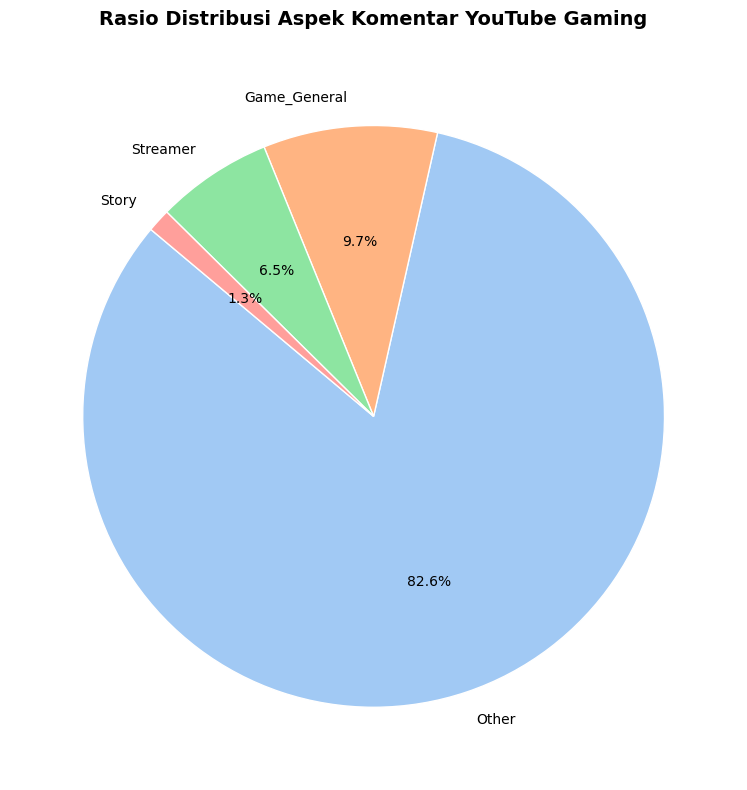


--- Menghasilkan Grafik Sentimen per Aspek ---


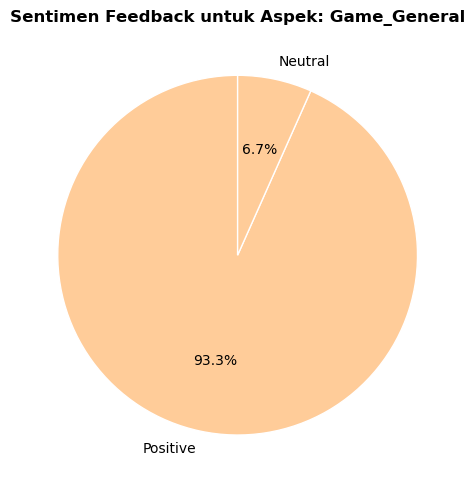

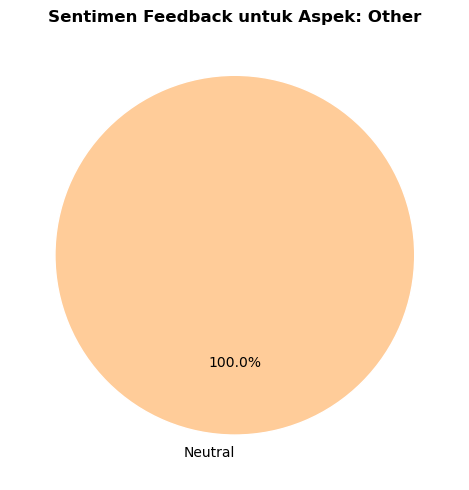

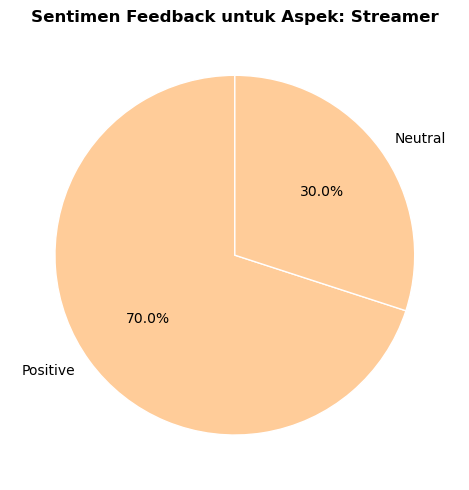

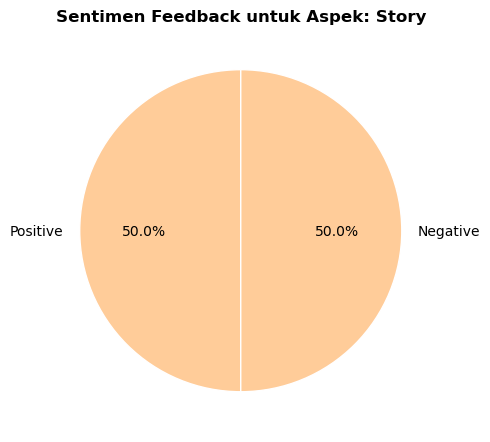

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. MENYIAPKAN DATA HASIL PREDIKSI
# Kita petakan kembali angka indeks (0-5) ke nama kelas aslinya agar diagram mudah dibaca
aspect_labels_map = {0: 'Game_General', 1: 'Gameplay', 2: 'Graphics', 3: 'Story', 4: 'Streamer', 5: 'Other'}
sentiment_labels_map = {0: 'Positive', 1: 'Negative', 2: 'Neutral'}

# Membuat DataFrame dari hasil pengujian (menggunakan variabel 'results' dari tahap evaluasi)
df_viz = pd.DataFrame({
    'Aspect': [aspect_labels_map[a] for a in results['aspect_pred']],
    'Sentiment': [sentiment_labels_map[s] for s in results['sentiment_pred']]
})

# Mengatur tema warna pastel yang rapi menggunakan seaborn
colors_aspect = sns.color_palette('pastel')[0:6]
colors_sentiment = ['#99ff99', '#ff9999', '#ffcc99'] # Hijau (Pos), Merah (Neg), Jingga (Neu)

# ========================================================
# VISUALISASI 1: ASPECT DISTRIBUTION (DIAGRAM LINGKARAN UTAMA)
# ========================================================
plt.figure(figsize=(8, 8))
aspect_counts = df_viz['Aspect'].value_counts()

plt.pie(
    aspect_counts, 
    labels=aspect_counts.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors_aspect,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1}
)
plt.title("Rasio Distribusi Aspek Komentar YouTube Gaming", fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('aspect_distribution.png', dpi=300) # Menyimpan grafik ke file lokal
plt.show()

# ========================================================
# VISUALISASI 2: SENTIMEN PER KELAS ASPEK (SUB-DIAGRAM)
# ========================================================
unique_aspects = df_viz['Aspect'].unique()
print("\n--- Menghasilkan Grafik Sentimen per Aspek ---")

for aspect in unique_aspects:
    # Filter data berdasarkan aspek spesifik
    df_sub = df_viz[df_viz['Aspect'] == aspect]
    sentiment_counts = df_sub['Sentiment'].value_counts()
    
    plt.figure(figsize=(5, 5))
    plt.pie(
        sentiment_counts, 
        labels=sentiment_counts.index, 
        autopct='%1.1f%%', 
        startangle=90, 
        colors=[colors_sentiment[sentiment_labels_map.get(s, 2)] for s in sentiment_counts.index],
        wedgeprops={'edgecolor': 'white', 'linewidth': 1}
    )
    plt.title(f"Sentimen Feedback untuk Aspek: {aspect}", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'sentiment_ratio_{aspect.lower().replace("/", "_")}.png', dpi=300)
    plt.show()